# ES-LSTM: Time Series Forecasting
## Notebook 02: Exponential Smoothing Grid Search
**Input:**  data/raw/*.csv  
**Output:** data/smoothed/*.csv · data/es_results.json · figures/heatmaps/ · figures/es_plots/

In [2]:
import os
import json
import yaml
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import (
    SimpleExpSmoothing, ExponentialSmoothing
)

warnings.filterwarnings('ignore')

with open('../config.yaml') as f:
    cfg = yaml.safe_load(f)

RAW_DIR      = f"../{cfg['paths']['raw_data']}"
SMOOTHED_DIR = f"../{cfg['paths']['smoothed']}"
FIG_ES       = f"../{cfg['paths']['figures']}/es_plots"
FIG_HEAT     = f"../{cfg['paths']['figures']}/heatmaps"

os.makedirs(SMOOTHED_DIR, exist_ok=True)
os.makedirs(FIG_HEAT,     exist_ok=True)

NAMES = list(cfg['data']['tickers'].keys())
print("Directories ready")
print("Datasets:", NAMES)

Directories ready
Datasets: ['SP500', 'NIFTY50', 'HDFCBANK', 'NATCOPHARMA']


>## `Load raw data`

In [3]:
datasets = {}
for name in NAMES:
    path = os.path.join(RAW_DIR, f"{name}.csv")
    df   = pd.read_csv(path, index_col=0, parse_dates=True)
    datasets[name] = df
    print(f"{name}: {len(df)} rows loaded")

SP500: 7216 rows loaded
NIFTY50: 4155 rows loaded
HDFCBANK: 7201 rows loaded
NATCOPHARMA: 7199 rows loaded


## SES grid search function

In [5]:
def ses_grid_search(series, verbose=False):
    """
    Grid search alpha in [0.1..0.9] for Simple Exponential Smoothing.
    Returns (best_alpha, best_mse, fitted_values, all_mse_list).
    """
    series    = np.array(series, dtype=float)
    best_alpha, best_mse, best_fitted = None, float('inf'), None
    all_mse   = []

    for alpha in np.round(np.arange(0.1, 1.0, 0.1), 2):
        model  = SimpleExpSmoothing(
            series, initialization_method='estimated'
        )
        result = model.fit(smoothing_level=alpha, optimized=False)
        fitted = result.fittedvalues
        error  = float(np.mean((series - fitted) ** 2))
        all_mse.append(error)

        if verbose:
            print(f"  SES α={alpha:.1f}  MSE={error:.4f}")
        if error < best_mse:
            best_mse, best_alpha, best_fitted = error, alpha, fitted

    return best_alpha, best_mse, best_fitted, all_mse


print("SES function defined")

SES function defined


## DES grid search function

In [6]:
def des_grid_search(series, verbose=False):
    """
    Grid search alpha x beta (81 combos) for Double Exponential Smoothing.
    Returns (best_alpha, best_beta, best_mse, fitted_values, mse_grid).
    """
    series     = np.array(series, dtype=float)
    best_params, best_mse, best_fitted = None, float('inf'), None
    alphas     = np.round(np.arange(0.1, 1.0, 0.1), 2)
    betas      = np.round(np.arange(0.1, 1.0, 0.1), 2)
    mse_grid   = np.full((len(betas), len(alphas)), np.nan)

    for ai, alpha in enumerate(alphas):
        for bi, beta in enumerate(betas):
            try:
                model  = ExponentialSmoothing(
                    series, trend='add',
                    initialization_method='estimated'
                )
                result = model.fit(
                    smoothing_level=alpha,
                    smoothing_trend=beta,
                    optimized=False
                )
                error  = float(np.mean((series - result.fittedvalues) ** 2))
                mse_grid[bi, ai] = error

                if error < best_mse:
                    best_mse    = error
                    best_params = (alpha, beta)
                    best_fitted = result.fittedvalues
            except Exception:
                continue

    return best_params[0], best_params[1], best_mse, best_fitted, mse_grid


print("DES function defined")

DES function defined


# Run grid search on all datasets

In [12]:
results_log  = {}
ses_mse_curves = {}
des_mse_grids  = {}

for name, df in datasets.items():
    series = df['Close'].values.astype(float)
    print(f"\n{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")

    # SES
    ses_a, ses_mse, ses_fit, ses_curve = ses_grid_search(series)
    print(f"  SES best → α={ses_a:.1f}   MSE={ses_mse:.6f}")

    # DES
    des_a, des_b, des_mse, des_fit, des_grid = des_grid_search(series)
    print(f"  DES best → α={des_a:.1f} β={des_b:.1f}  MSE={des_mse:.6f}")

    # Pick winner
    if ses_mse <= des_mse:
        winner, best_fit = 'SES', ses_fit
        params = {'alpha': float(ses_a)}
    else:
        winner, best_fit = 'DES', des_fit
        params = {'alpha': float(des_a), 'beta': float(des_b)}

    print(f"  Winner → {winner}  (MSE={min(ses_mse, des_mse):.6f})")

    # Save smoothed column
    df = df.copy()
    df['Close_smoothed'] = best_fit
    df.to_csv(os.path.join(SMOOTHED_DIR, f"{name}.csv"))
    datasets[name] = df

    results_log[name]    = {
        'method':   winner,
        'params':   params,
        'mse':      float(min(ses_mse, des_mse)),
        'ses_mse':  float(ses_mse),
        'des_mse':  float(des_mse),
    }
    ses_mse_curves[name] = ses_curve
    des_mse_grids[name]  = des_grid

# Save results log
with open('../data/es_results.json', 'w') as f:
    json.dump(results_log, f, indent=2)

print("\n\nGrid search complete. Results saved to data/es_results.json")


  SP500
  SES best → α=0.9   MSE=590.044241
  DES best → α=0.9 β=0.1  MSE=620.109249
  Winner → SES  (MSE=590.044241)

  NIFTY50
  SES best → α=0.9   MSE=12762.907014
  DES best → α=0.9 β=0.1  MSE=13238.882158
  Winner → SES  (MSE=12762.907014)

  HDFCBANK
  SES best → α=0.9   MSE=23.605398
  DES best → α=0.9 β=0.1  MSE=24.788210
  Winner → SES  (MSE=23.605398)

  NATCOPHARMA
  SES best → α=0.9   MSE=83.495327
  DES best → α=0.9 β=0.1  MSE=86.796962
  Winner → SES  (MSE=83.495327)


Grid search complete. Results saved to data/es_results.json


## Print summary table

In [13]:
print(f"\n{'Dataset':<15} {'Method':<6} {'Alpha':>7} {'Beta':>7} {'MSE':>12}")
print("-" * 52)
for name, info in results_log.items():
    a = info['params'].get('alpha', '—')
    b = info['params'].get('beta',  '—')
    print(f"{name:<15} {info['method']:<6} {str(a):>7} {str(b):>7} {info['mse']:>12.6f}")


Dataset         Method   Alpha    Beta          MSE
----------------------------------------------------
SP500           SES        0.9       —   590.044241
NIFTY50         SES        0.9       — 12762.907014
HDFCBANK        SES        0.9       —    23.605398
NATCOPHARMA     SES        0.9       —    83.495327


## Fig 5: DES heatmaps

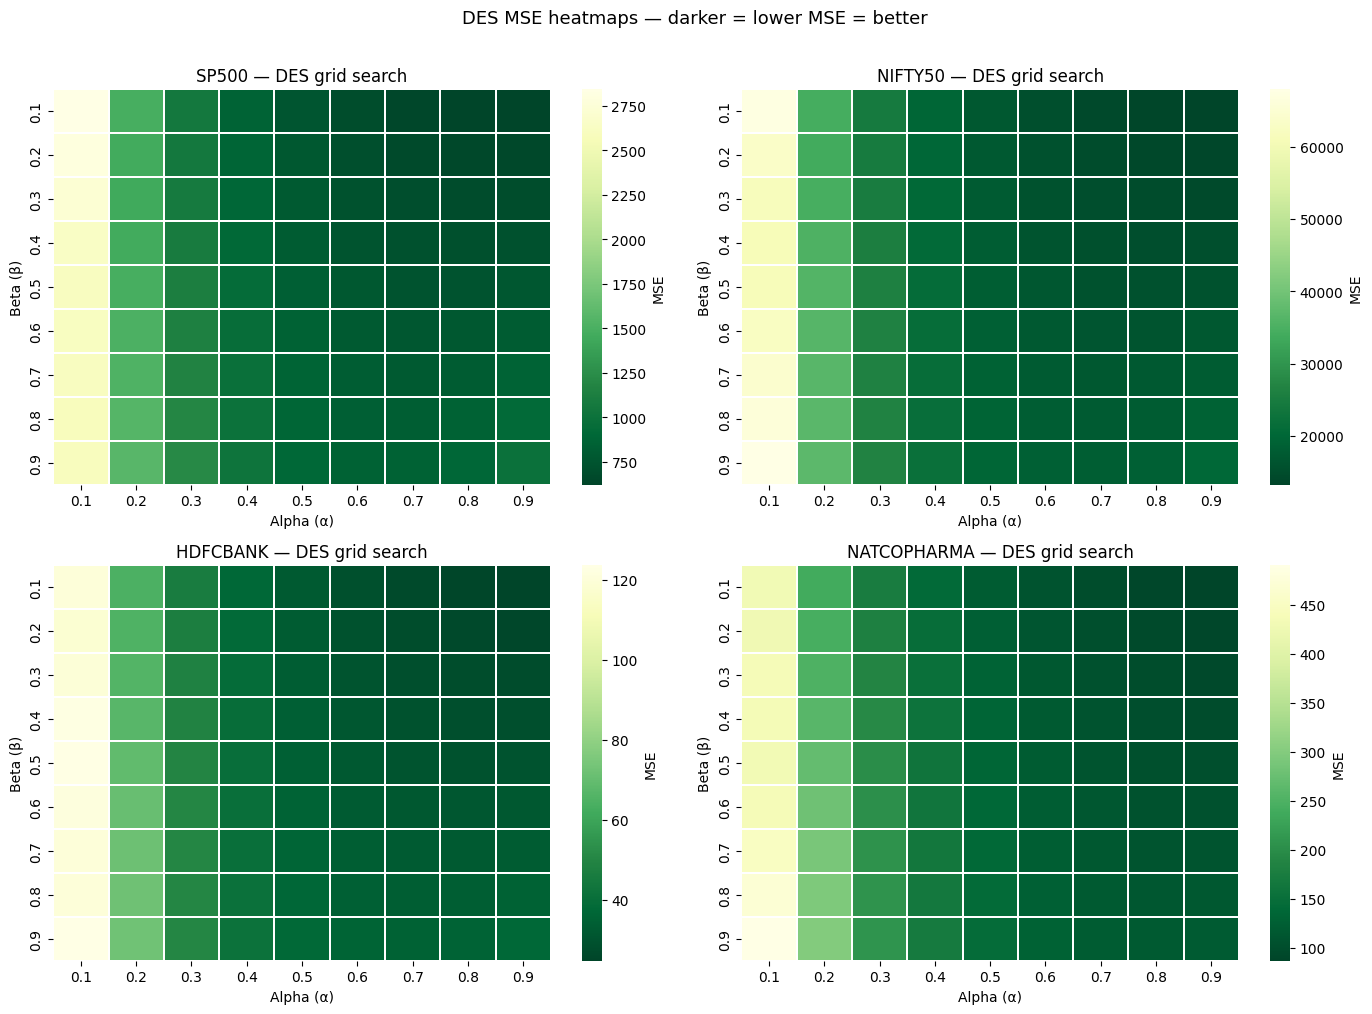

Fig 5 saved


In [14]:
alphas = np.round(np.arange(0.1, 1.0, 0.1), 2)
betas  = np.round(np.arange(0.1, 1.0, 0.1), 2)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, name in zip(axes.flat, NAMES):
    grid = des_mse_grids[name]
    sns.heatmap(
        grid,
        xticklabels=[f'{a:.1f}' for a in alphas],
        yticklabels=[f'{b:.1f}' for b in betas],
        cmap='YlGn_r', ax=ax, linewidths=0.3,
        cbar_kws={'label': 'MSE'}
    )
    # Mark the best cell
    best_a = results_log[name]['params']['alpha']
    best_b = results_log[name]['params'].get('beta', None)
    if best_b is not None:
        ai = list(alphas).index(round(best_a, 1))
        bi = list(betas).index(round(best_b, 1))
        ax.add_patch(plt.Rectangle((ai, bi), 1, 1,
                     fill=False, edgecolor='red', lw=2.5))
    ax.set_title(f'{name} — DES grid search', fontsize=12)
    ax.set_xlabel('Alpha (α)'); ax.set_ylabel('Beta (β)')

plt.suptitle('DES MSE heatmaps — darker = lower MSE = better',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f'{FIG_HEAT}/fig5_des_heatmaps.png', dpi=300, bbox_inches='tight')
plt.show()
print("Fig 5 saved")

## Fig 6: Raw vs smoothed overlay

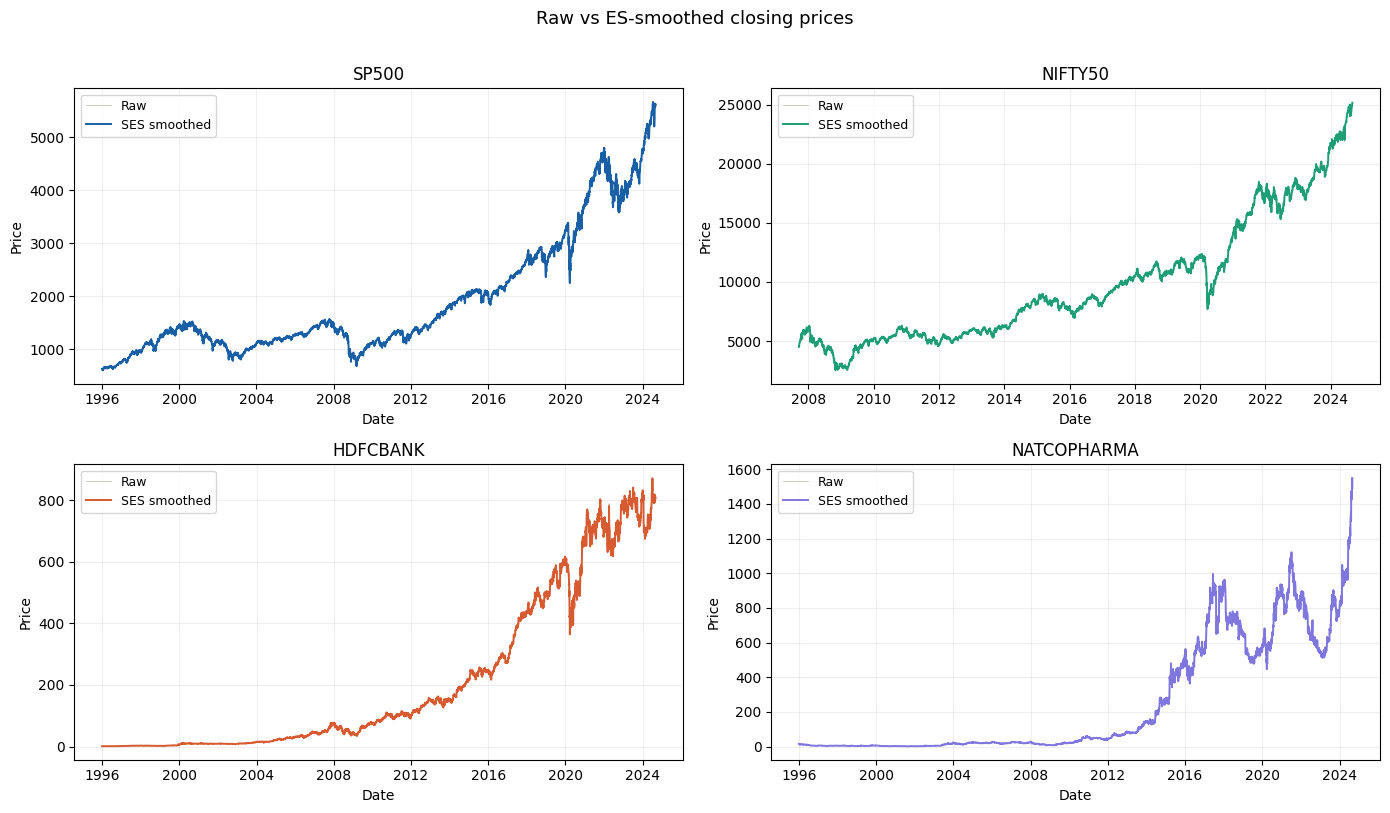

Fig 6 saved


In [15]:
colors = ['#185FA5', '#1D9E75', '#D85A30', '#7F77DD']
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, (name, df), color in zip(axes.flat, datasets.items(), colors):
    ax.plot(df.index, df['Close'],
            color='#B4B2A9', lw=0.6, label='Raw', alpha=0.8)
    ax.plot(df.index, df['Close_smoothed'],
            color=color, lw=1.4, label=f"{results_log[name]['method']} smoothed")
    ax.set_title(name, fontsize=12)
    ax.set_xlabel('Date'); ax.set_ylabel('Price')
    ax.legend(fontsize=9); ax.grid(alpha=0.2)

plt.suptitle('Raw vs ES-smoothed closing prices', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f'{FIG_ES}/fig6_raw_vs_smoothed.png', dpi=300, bbox_inches='tight')
plt.show()
print("Fig 6 saved")

## Fig 7: Residuals

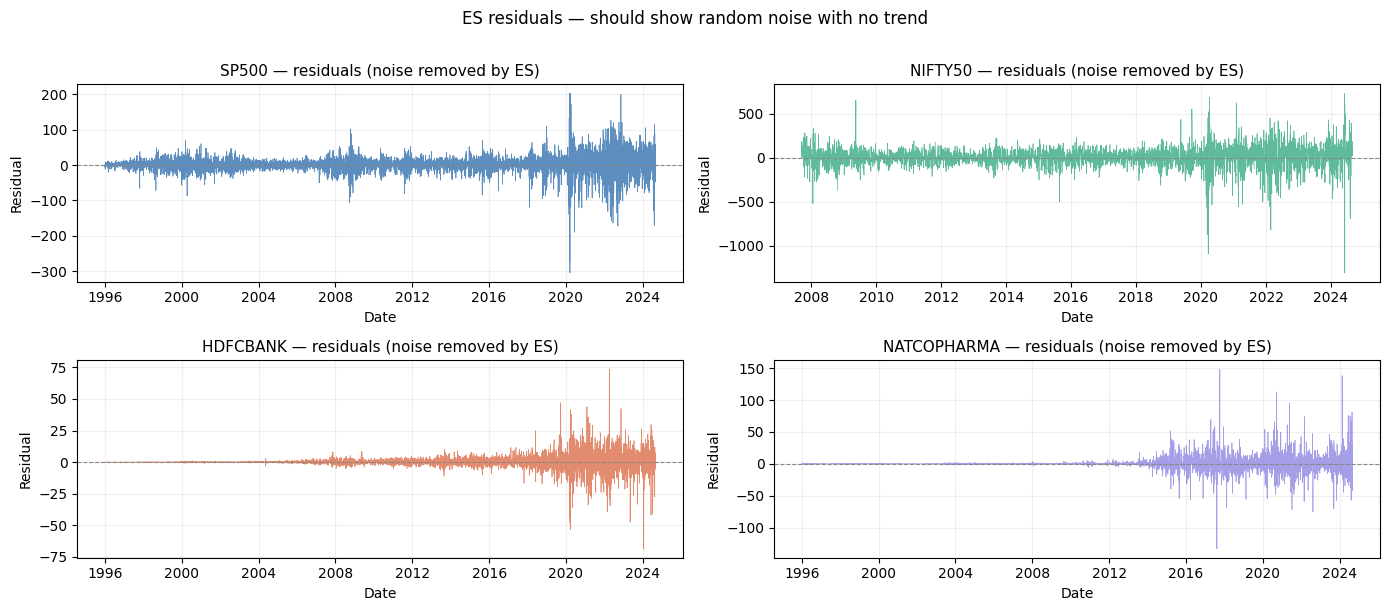

Fig 7 saved


In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 6))

for ax, (name, df), color in zip(axes.flat, datasets.items(), colors):
    resid = df['Close'] - df['Close_smoothed']
    ax.plot(df.index, resid, lw=0.5, color=color, alpha=0.7)
    ax.axhline(0, color='#888', lw=0.8, ls='--')
    ax.set_title(f'{name} — residuals (noise removed by ES)', fontsize=11)
    ax.set_xlabel('Date'); ax.set_ylabel('Residual')
    ax.grid(alpha=0.2)

plt.suptitle('ES residuals — should show random noise with no trend',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(f'{FIG_ES}/fig7_residuals.png', dpi=300, bbox_inches='tight')
plt.show()
print("Fig 7 saved")

## ES Grid Search Summary

- SES searched 9 alpha values per dataset
- DES searched 81 (alpha × beta) combinations per dataset  
- Winner selected per dataset based on lowest MSE
- Smoothed series saved to data/smoothed/*.csv
- Results log saved to data/es_results.json
- Proceed to: `03_lstm_train.ipynb`
```

---

Run all cells top to bottom. Cell 6 is the slowest — the DES grid search runs 81 combinations × 4 datasets = 324 model fits. Expect about 2–3 minutes.

When done you should have:
```
data/smoothed/SP500.csv
data/smoothed/NIFTY50.csv  
data/smoothed/HDFCBANK.csv
data/smoothed/NATCOPHARMA.csv
data/es_results.json
figures/heatmaps/fig5_des_heatmaps.png
figures/es_plots/fig6_raw_vs_smoothed.png
figures/es_plots/fig7_residuals.png